# BÀI 2: TINH CHỈNH MÔ HÌNH PRE-TRAINED CHO TÓM TẮT VĂN BẢN

Đề tài: Xây dựng hệ thống tóm tắt văn bản tự động.
Phương pháp: Fine-tune mô hình pre-trained **VietAI/vit5-base** (< 3B tham số) cho bài toán Abstractive Summarization, kết hợp cải tiến **LoRA** (PEFT) và **học tăng cường SCST**.

## 1. Thiết lập môi trường và cài đặt thư viện

In [1]:
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.

In [2]:
# Cài đặt thư viện (phiên bản đã kiểm thử)
!pip install -q transformers==4.48.3 tokenizers==0.21.4 datasets peft evaluate rouge-score sacrebleu sentencepiece gdown accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.1 MB/s eta 0:00:00


In [3]:
# Workaround: ẩn torchao để tránh lỗi tương thích PEFT/transformers.
# Tự phục hồi qua reload nên an toàn kể cả khi chạy lại nhiều lần.
import sys, importlib, importlib.metadata, importlib.util

importlib.reload(importlib.metadata)
importlib.reload(importlib.util)
_pristine_version = importlib.metadata.version
_pristine_find_spec = importlib.util.find_spec

def my_version(package_name):
    if package_name == "torchao":
        raise importlib.metadata.PackageNotFoundError(package_name)
    return _pristine_version(package_name)

def my_find_spec(name, package=None):
    if name == "torchao":
        return None
    return _pristine_find_spec(name, package)

importlib.metadata.version = my_version
importlib.util.find_spec = my_find_spec
if "torchao" in sys.modules:
    del sys.modules["torchao"]
print('torchao monkey-patch OK')

import os, json, time, gc, math, random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from datasets import Dataset as HFDataset
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

def free_mem():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def _detect_env():
    import os as _os
    # Kaggle kiểm tra trước (máy Kaggle cũng có package google.colab)
    if _os.path.exists('/kaggle') or _os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    try:
        import google.colab  # noqa: F401
        if _os.path.exists('/content'):
            return 'colab'
    except Exception:
        pass
    return 'local'
ENV = _detect_env()

def mount_drive():
    if ENV == 'colab':
        if not os.path.exists('/content/drive/MyDrive'):
            from google.colab import drive
            drive.mount('/content/drive')
        print('Drive đã sẵn sàng')
    else:
        print(f'Môi trường = {ENV} → bỏ qua mount Google Drive')

mount_drive()

torchao monkey-patch OK


2026-06-10 15:37:53.145879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781105873.363233      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781105873.431438      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781105873.964157      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781105873.964201      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781105873.964204      23 computation_placer.cc:177] computation placer alr

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Môi trường = kaggle → bỏ qua mount Google Drive


## 2. Cấu hình & siêu tham số (Configuration)

In [4]:
# ENV tính lại để cell tự chạy độc lập
def _detect_env():
    import os as _os
    if _os.path.exists('/kaggle') or _os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    try:
        import google.colab  # noqa: F401
        if _os.path.exists('/content'):
            return 'colab'
    except Exception:
        pass
    return 'local'
ENV = _detect_env()
if ENV == 'colab':
    WORK_DIR   = Path('/content/work')
    DRIVE_ROOT = Path('/content/drive/MyDrive/nlp_summarization')
elif ENV == 'kaggle':
    WORK_DIR   = Path('/kaggle/working/work')
    DRIVE_ROOT = Path('/kaggle/working/nlp_summarization')
else:
    WORK_DIR   = Path('./work')
    DRIVE_ROOT = Path('./nlp_summarization')
print(f'ENV={ENV} | WORK_DIR={WORK_DIR} | DRIVE_ROOT={DRIVE_ROOT}')

@dataclass
class Config:
    data_dir: Path = WORK_DIR / 'data'
    drive_data_dir: Path = DRIVE_ROOT / 'data'
    ckpt_dir: Path = DRIVE_ROOT / 'checkpoints_pretrained'

    model_name: str = 'VietAI/vit5-base'      # mô hình pre-trained < 3B tham số

    max_src_len: int = 512
    max_tgt_len: int = 128

    batch_size: int = 8
    gradient_accumulation_steps: int = 4
    learning_rate: float = 3e-4
    num_epochs: int = 5
    warmup_ratio: float = 0.1
    weight_decay: float = 0.01
    use_fp16: bool = True

    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.1

    seed: int = 42

cfg = Config()
for p in [cfg.data_dir, cfg.drive_data_dir, cfg.ckpt_dir]:
    p.mkdir(parents=True, exist_ok=True)

# Kaggle: dùng Dataset đính kèm nếu có (khỏi tải lại bằng gdown)
if ENV == 'kaggle':
    import glob
    hits = (glob.glob('/kaggle/input/**/*train*.parquet', recursive=True)
            + glob.glob('/kaggle/input/**/*train*.csv', recursive=True)
            + glob.glob('/kaggle/input/**/*train*.json*', recursive=True))
    if hits:
        cfg.drive_data_dir = Path(hits[0]).parent
        print('Phát hiện data trong Kaggle Dataset:', cfg.drive_data_dir)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)
print('Cấu hình hoàn tất!')

ENV=kaggle | WORK_DIR=/kaggle/working/work | DRIVE_ROOT=/kaggle/working/nlp_summarization
Cấu hình hoàn tất!


## 3. Chuẩn bị dữ liệu (Data Preparation)

In [5]:
print('Đang đồng bộ dữ liệu...')
SUPPORTED_EXT = ['.parquet', '.csv', '.jsonl', '.json']

drive_files = [p for p in cfg.drive_data_dir.iterdir() if p.is_file() and p.suffix.lower() in SUPPORTED_EXT]
if not drive_files:
    print('Data trống → tải từ liên kết chia sẻ...')
    import gdown
    DATA_FOLDER_ID = '1Jm-K5E9bHbj1WIofWKx-YuAAIaEa9gnc'
    gdown.download_folder(
        f'https://drive.google.com/drive/folders/{DATA_FOLDER_ID}',
        output=str(cfg.drive_data_dir), quiet=False, use_cookies=False
    )
    drive_files = [p for p in cfg.drive_data_dir.iterdir() if p.is_file() and p.suffix.lower() in SUPPORTED_EXT]

# Sao chép sang local để tăng tốc đọc/ghi
for src in drive_files:
    dst = cfg.data_dir / src.name
    if not dst.exists() or dst.stat().st_size != src.stat().st_size:
        import shutil
        shutil.copy2(src, dst)
        print(f'  ✓ Copied {src.name}')

def find_split(keyword):
    cand = []
    for ext in SUPPORTED_EXT:
        cand += sorted(cfg.data_dir.glob(f'*{keyword}*{ext}'))
    if not cand:
        raise FileNotFoundError(f'Không tìm thấy file chứa "{keyword}" trong {cfg.data_dir}')
    return cand[0]

train_path = find_split('train')
valid_path = find_split('valid') if list(cfg.data_dir.glob('*valid*')) else find_split('val')
print('Train:', train_path.name, '| Valid:', valid_path.name)

def read_any(path):
    e = path.suffix.lower()
    if e == '.parquet': return pd.read_parquet(path)
    if e == '.csv':     return pd.read_csv(path)
    if e == '.json':    return pd.read_json(path)
    if e == '.jsonl':   return pd.read_json(path, lines=True)
    raise ValueError(e)

raw_train = read_any(train_path)
raw_valid = read_any(valid_path)

# Dò cột source/target tự động (đồng bộ với Bài 1)
SRC_CANDS = ['source', 'article', 'document', 'text', 'content', 'body', 'input', 'src', 'context', 'passage']
TGT_CANDS = ['target', 'summary', 'abstract', 'highlights', 'headline', 'title', 'tgt', 'output', 'label']
cols_lower = {c.lower(): c for c in raw_train.columns}
src_col = next((cols_lower[k] for k in SRC_CANDS if k in cols_lower), None)
tgt_col = next((cols_lower[k] for k in TGT_CANDS if k in cols_lower), None)
if src_col is None or tgt_col is None:
    if len(raw_train.columns) == 2:
        c1, c2 = raw_train.columns
        src_col, tgt_col = (c1, c2) if raw_train[c1].astype(str).str.len().mean() >= raw_train[c2].astype(str).str.len().mean() else (c2, c1)
    else:
        raise ValueError('Không xác định được cột source/target.')

print(f'SOURCE: {src_col!r} | TARGET: {tgt_col!r}')
print(f'Train: {len(raw_train):,} | Valid: {len(raw_valid):,}')

# ============================================================
# LÀM SẠCH VĂN BẢN (TEXT CLEANING)
# Xử lý các lỗi thường gặp khi crawl dữ liệu tiếng Việt:
#  - Chuẩn hoá Unicode (NFC) để gộp dấu tổ hợp về dạng dựng sẵn
#  - Xoá ký tự điều khiển / zero-width / khoảng trắng lạ
#  - Gỡ thẻ HTML, URL, email còn sót lại
#  - Tách chữ bị dính: "caGặp" -> "ca Gặp", "60có" -> "60 có", "ta60" -> "ta 60"
#  - Chuẩn hoá dấu câu lặp và khoảng trắng quanh dấu câu
# ============================================================
import re, unicodedata

_RE_URL   = re.compile(r'https?://\S+|www\.\S+')
_RE_EMAIL = re.compile(r'\S+@\S+\.\S+')
_RE_HTML  = re.compile(r'<[^>]+>')
_RE_ZW    = re.compile(r'[\u200b\u200c\u200d\ufeff\u00ad\u2060]')      # zero-width & soft hyphen
_RE_CTRL  = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]')            # control chars (giữ \t \n)
# dính chữ thường + HOA (camelCase do mất dấu cách): "caGặp" -> "ca Gặp"
_RE_GLUE_CASE = re.compile(r'([a-zàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ])'
                           r'([A-ZÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬÈÉẺẼẸÊỀẾỂỄỆÌÍỈĨỊÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢÙÚỦŨỤƯỪỨỬỮỰỲÝỶỸỴĐ])')
_RE_GLUE_NUM_L = re.compile(r'(\d)([^\W\d_])')                         # "60có" -> "60 có"
_RE_GLUE_L_NUM = re.compile(r'([^\W\d_])(\d)')                         # "ta60" -> "ta 60"
# Token chữ cái dài bất thường (>= 18 ký tự không dấu cách) -> dấu hiệu chữ bị dính
# kiểu "Tronglễvuquy". Loại lỗi này nhập nhằng, không tự sửa an toàn được nên ta
# DÙNG NÓ LÀM TÍN HIỆU LỌC (xem phần lọc cặp bên dưới) thay vì đoán mò.
_RE_LONG_GLUE = re.compile(r'[^\W\d_]{18,}', re.UNICODE)
_RE_MULTI_PUNCT = re.compile(r'([.,!?;:])\1{1,}')                      # "..." giữ, "!!" -> "!"
_RE_SPACE_BEFORE_PUNCT = re.compile(r'\s+([.,!?;:%)\]}])')
_RE_SPACE_AFTER_OPEN   = re.compile(r'([(\[{])\s+')
_RE_WS    = re.compile(r'[ \t\u00a0\u2000-\u200a\u202f\u205f\u3000]+') # gộp khoảng trắng
_RE_NL    = re.compile(r'\s*\n\s*')

def clean_text(s):
    if not isinstance(s, str):
        s = str(s)
    s = unicodedata.normalize('NFC', s)
    s = _RE_ZW.sub('', s)
    s = _RE_HTML.sub(' ', s)
    s = _RE_URL.sub(' ', s)
    s = _RE_EMAIL.sub(' ', s)
    s = _RE_CTRL.sub(' ', s)
    s = _RE_GLUE_CASE.sub(r'\1 \2', s)
    s = _RE_GLUE_NUM_L.sub(r'\1 \2', s)
    s = _RE_GLUE_L_NUM.sub(r'\1 \2', s)
    s = _RE_MULTI_PUNCT.sub(r'\1', s)
    s = _RE_NL.sub(' ', s)
    s = _RE_WS.sub(' ', s)
    s = _RE_SPACE_BEFORE_PUNCT.sub(r'\1', s)
    s = _RE_SPACE_AFTER_OPEN.sub(r'\1', s)
    return s.strip()

# ============================================================
# LỌC CẶP (src, tgt) KÉM CHẤT LƯỢNG
# ============================================================
MIN_SRC_WORDS = 20      # bài quá ngắn -> bỏ
MAX_SRC_WORDS = 1500    # bài quá dài bất thường -> bỏ
MIN_TGT_WORDS = 5
MAX_TGT_WORDS = 200
MIN_RATIO = 1.2         # source phải dài hơn summary đáng kể
MAX_RATIO = 60.0        # summary quá ngắn so với source -> nghi ngờ
MAX_GLUE_TOKENS = 2     # số token chữ-dính-dài tối đa cho phép trong 1 source

def prep(df, name='', drop_dup=True):
    n0 = len(df)
    df = df[[src_col, tgt_col]].dropna().copy()
    df[src_col] = df[src_col].astype(str).map(clean_text)
    df[tgt_col] = df[tgt_col].astype(str).map(clean_text)

    # bỏ rỗng sau khi làm sạch
    df = df[(df[src_col].str.len() > 0) & (df[tgt_col].str.len() > 0)]

    sw = df[src_col].str.split().map(len)
    tw = df[tgt_col].str.split().map(len)
    ratio = sw / tw.clip(lower=1)
    # đếm số "token dính dài bất thường" trong source -> nhiều thì nghi văn bản rác
    n_glue = df[src_col].str.count(_RE_LONG_GLUE.pattern)
    keep = (sw.between(MIN_SRC_WORDS, MAX_SRC_WORDS)
            & tw.between(MIN_TGT_WORDS, MAX_TGT_WORDS)
            & ratio.between(MIN_RATIO, MAX_RATIO)
            & (n_glue <= MAX_GLUE_TOKENS)
            & (df[src_col] != df[tgt_col]))            # src trùng tgt -> bỏ
    df = df[keep]

    if drop_dup:
        df = df.drop_duplicates(subset=[src_col])      # trùng source -> giữ 1
        df = df.drop_duplicates(subset=[tgt_col])      # trùng summary -> giữ 1

    df = df.reset_index(drop=True)
    print(f'  [{name}] {n0} -> {len(df)} cặp (loại {n0-len(df)})')
    return pd.DataFrame({src_col: df[src_col].values, tgt_col: df[tgt_col].values})

print('Làm sạch & lọc dữ liệu...')
train_df = prep(raw_train, 'train')
valid_df = prep(raw_valid, 'valid')

# Chống rò rỉ: bỏ mẫu valid trùng source với train
_train_src_set = set(train_df[src_col])
_before = len(valid_df)
valid_df = valid_df[~valid_df[src_col].isin(_train_src_set)].reset_index(drop=True)
if _before != len(valid_df):
    print(f'  [leak] loại {_before-len(valid_df)} mẫu valid trùng train')

del raw_train, raw_valid; free_mem()
print(f'SOURCE={src_col!r} TARGET={tgt_col!r} | train={len(train_df)} valid={len(valid_df)}')

Đang đồng bộ dữ liệu...
Data trống → tải từ liên kết chia sẻ...


Retrieving folder contents


Processing file 1yCxwkiwziwt4Jpug79-ui65XqjKjQdot train-00000-of-00001.parquet
Processing file 1Y2jQlytvwVu0R-gLYy7N0FajLTCsSHmH valid-00000-of-00001.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1yCxwkiwziwt4Jpug79-ui65XqjKjQdot
To: /kaggle/working/nlp_summarization/data/train-00000-of-00001.parquet
100%|██████████| 18.7M/18.7M [00:00<00:00, 64.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Y2jQlytvwVu0R-gLYy7N0FajLTCsSHmH
To: /kaggle/working/nlp_summarization/data/valid-00000-of-00001.parquet
100%|██████████| 2.38M/2.38M [00:00<00:00, 169MB/s]
Download completed


  ✓ Copied train-00000-of-00001.parquet
  ✓ Copied valid-00000-of-00001.parquet
Train: train-00000-of-00001.parquet | Valid: valid-00000-of-00001.parquet
SOURCE: 'article' | TARGET: 'summary'
Train: 10,775 | Valid: 1,349
Làm sạch & lọc dữ liệu...
  [train] 10775 -> 10772 cặp (loại 3)
  [valid] 1349 -> 1349 cặp (loại 0)
SOURCE='article' TARGET='summary' | train=10772 valid=1349


## 4. Tokenization & tiền xử lý dữ liệu

In [6]:
print(f'Tải tokenizer: {cfg.model_name}')
# use_fast=False để dùng SentencePiece, tránh lỗi Unigram conversion trên HF mới
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=False)

def preprocess_function(examples):
    prefix = "summarize: " if "t5" in cfg.model_name.lower() else ""   # T5 cần prefix tác vụ
    inputs = [prefix + doc for doc in examples[src_col]]
    model_inputs = tokenizer(inputs, max_length=cfg.max_src_len, truncation=True, padding=False)
    labels = tokenizer(text_target=examples[tgt_col], max_length=cfg.max_tgt_len, truncation=True, padding=False)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

hf_train = HFDataset.from_pandas(train_df)
hf_valid = HFDataset.from_pandas(valid_df)
tokenized_train = hf_train.map(preprocess_function, batched=True, remove_columns=[src_col, tgt_col])
tokenized_valid = hf_valid.map(preprocess_function, batched=True, remove_columns=[src_col, tgt_col])
print('Tokenize xong | ví dụ input_ids:', tokenized_train[0]['input_ids'][:10])

Tải tokenizer: VietAI/vit5-base


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Map:   0%|          | 0/10772 [00:00<?, ? examples/s]

Map:   0%|          | 0/1349 [00:00<?, ? examples/s]

Tokenize xong | ví dụ input_ids: [10082, 2359, 8013, 35862, 3205, 60, 35846, 221, 1044, 74]


## 5. Cấu hình Parameter-Efficient Fine-Tuning (PEFT/LoRA)

Áp dụng **LoRA (Low-Rank Adaptation)**: đóng băng trọng số pre-trained, chỉ huấn luyện các ma trận hạng thấp chèn vào khối Attention → giảm tham số huấn luyện xuống dưới 3%, tiết kiệm VRAM và hạn chế overfitting.

In [7]:
print(f'Khởi tạo mô hình gốc: {cfg.model_name}')
model = AutoModelForSeq2SeqLM.from_pretrained(cfg.model_name)

lora_config = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    target_modules=["q", "v"],          # query/value của Self & Cross Attention
    lora_dropout=cfg.lora_dropout,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Khởi tạo mô hình gốc: VietAI/vit5-base


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/904M [00:00<?, ?B/s]

trainable params: 1,769,472 || all params: 227,720,448 || trainable%: 0.7770


## 6. Thiết lập hàm đánh giá (ROUGE & BLEU)

In [8]:
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]
    # -100 (padding nhãn) → pad_token_id trước khi decode
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds = [p.strip() for p in tokenizer.batch_decode(preds, skip_special_tokens=True)]
    decoded_labels = [l.strip() for l in tokenizer.batch_decode(labels, skip_special_tokens=True)]
    rouge_results = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    bleu_results = bleu_metric.compute(predictions=decoded_preds, references=[[l] for l in decoded_labels])
    return {
        "rouge1": round(rouge_results["rouge1"] * 100, 2),
        "rouge2": round(rouge_results["rouge2"] * 100, 2),
        "rougeL": round(rouge_results["rougeL"] * 100, 2),
        "bleu": round(bleu_results["score"], 2)
    }

model.safetensors:   0%|          | 0.00/904M [00:00<?, ?B/s]

## 7. Huấn luyện mô hình (Fine-tuning)

In [9]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8)

training_args = Seq2SeqTrainingArguments(
    output_dir=str(cfg.ckpt_dir),
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=cfg.learning_rate,
    per_device_train_batch_size=cfg.batch_size,
    per_device_eval_batch_size=cfg.batch_size,
    gradient_accumulation_steps=cfg.gradient_accumulation_steps,
    weight_decay=cfg.weight_decay,
    num_train_epochs=cfg.num_epochs,
    warmup_ratio=cfg.warmup_ratio,
    logging_steps=10,
    save_total_limit=2,
    fp16=cfg.use_fp16,
    predict_with_generate=True,          # sinh văn bản để chấm ROUGE khi eval
    generation_max_length=cfg.max_tgt_len,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print('Bắt đầu fine-tuning...')
train_result = trainer.train()
trainer.save_model(str(cfg.ckpt_dir / 'best_model'))
print('Huấn luyện xong, đã lưu checkpoint.')

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_23/2311851195.py:25: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Bắt đầu fine-tuning...


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
1,1.269700,1.118032,66.320000,36.160000,43.550000,23.570000
2,1.192800,1.097625,70.320000,40.710000,46.010000,28.580000
3,1.183600,1.068083,70.980000,41.320000,46.440000,28.340000
4,1.104200,1.049599,71.470000,42.330000,47.030000,29.530000


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Huấn luyện xong, đã lưu checkpoint.


## 8. Dự đoán & đánh giá định tính (Inference)

In [10]:
print('Nạp trọng số LoRA tốt nhất...')
base_model = AutoModelForSeq2SeqLM.from_pretrained(cfg.model_name)
peft_model = PeftModel.from_pretrained(base_model, str(cfg.ckpt_dir / 'best_model'))
peft_model.to(device)
peft_model.eval()

def summarize_vietnamese(text, max_length=cfg.max_tgt_len, num_beams=4):
    prefix = "summarize: " if "t5" in cfg.model_name.lower() else ""
    inputs = tokenizer(prefix + text, return_tensors="pt", max_length=cfg.max_src_len, truncation=True).to(device)
    with torch.no_grad():
        outputs = peft_model.generate(
            input_ids=inputs["input_ids"],
            max_length=max_length,
            num_beams=num_beams,
            no_repeat_ngram_size=3,
            early_stopping=True
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print('\n=== ĐÁNH GIÁ ĐỊNH TÍNH ===\n')
random.seed(cfg.seed)
for idx in random.sample(range(len(valid_df)), 3):
    source_text = valid_df.iloc[idx][src_col]
    reference_text = valid_df.iloc[idx][tgt_col]
    predicted_summary = summarize_vietnamese(source_text)
    print(f'- Ví dụ {idx}:')
    print(f'  SOURCE: {source_text[:300]}...')
    print(f'  REF   : {reference_text}')
    print(f'  PRED  : {predicted_summary}')
    print('-' * 80)

Nạp trọng số LoRA tốt nhất...

=== ĐÁNH GIÁ ĐỊNH TÍNH ===

- Ví dụ 1309:
  SOURCE: Theo quyết định ngày 16/10 do Phó thủ tướng Trần Hồng Hà ký, sân bay Cà Mau được nâng cấp, mở rộng đảm bảo khai thác máy bay A 320, A 321 và tương đương. Đường lăn và sân đỗ máy bay phía Nam sẽ được xây dựng. Sân đỗ đáp ứng ba vị trí đỗ máy bay. Nhà ga hành khách được mở rộng, gồm hai tầng với diện ...
  REF   : Sân bay Cà Mau sẽ được nâng cấp, mở rộng để đảm bảo khai thác máy bay A 320, A 321 và tương đương. Dự án bao gồm xây dựng đường lăn, sân đỗ máy bay, mở rộng nhà ga hành khách lên 2 tầng với diện tích 2.660 m 2, đón 500.000 khách mỗi năm. Dự án do Tổng công ty Cảng hàng không Việt Nam (ACV) đảm trách, tỉnh Cà Mau sẽ kiểm tra, giám sát việc triển khai. Sân bay Cà Mau hiện có công suất 200.000 khách mỗi năm, dự kiến nâng cấp lên công suất 1 triệu khách mỗi năm đến năm 2030 và 3 triệu khách mỗi năm đến năm 2050.
  PRED  : Sân bay Cà Mau được nâng cấp, mở rộng đảm bảo khai thác máy bay A 320, A321 và 

## 9. Biểu đồ loss

Vẽ đường loss huấn luyện và ROUGE-L trên valid, trích từ `trainer.state.log_history`.

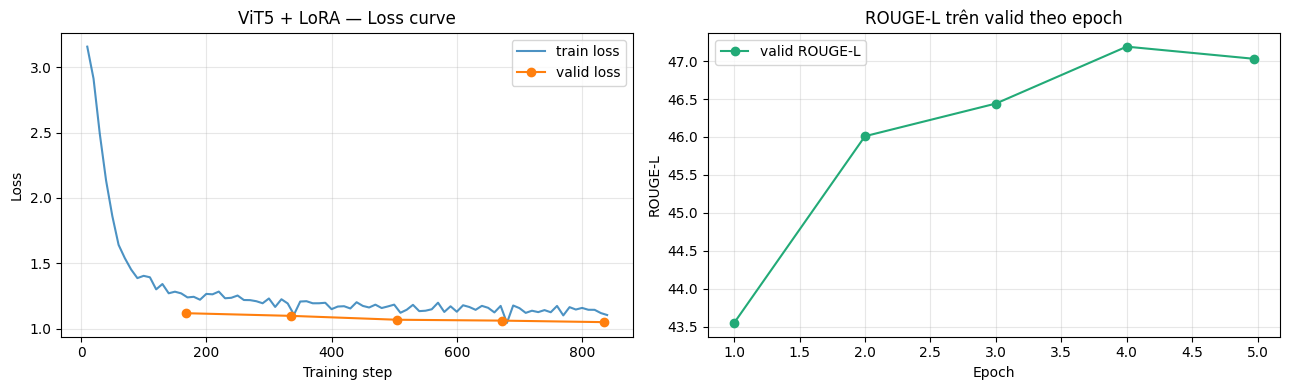

Đã lưu biểu đồ loss: /kaggle/working/nlp_summarization/checkpoints_pretrained/pretrained_loss.png


In [11]:
import matplotlib.pyplot as plt
import json as _json

log = trainer.state.log_history
train_steps = [(e['step'], e['loss']) for e in log if 'loss' in e and 'eval_loss' not in e]
eval_epochs = [(e.get('epoch'), e.get('eval_loss')) for e in log if 'eval_loss' in e]
eval_rouge  = [(e.get('epoch'), e.get('eval_rougeL')) for e in log if 'eval_rougeL' in e]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
if train_steps:
    xs, ys = zip(*train_steps); ax[0].plot(xs, ys, label='train loss', alpha=0.8)
if eval_epochs and eval_epochs[0][0] is not None:
    steps_per_epoch = max((s for s, _ in train_steps), default=1) / max(cfg.num_epochs, 1)
    ex = [ep * steps_per_epoch for ep, _ in eval_epochs]; ey = [v for _, v in eval_epochs]
    ax[0].plot(ex, ey, 'o-', label='valid loss')
ax[0].set_xlabel('Training step'); ax[0].set_ylabel('Loss')
ax[0].set_title('ViT5 + LoRA — Loss curve'); ax[0].legend(); ax[0].grid(alpha=0.3)

if eval_rouge and eval_rouge[0][0] is not None:
    rx = [ep for ep, _ in eval_rouge]; ry = [v for _, v in eval_rouge]
    ax[1].plot(rx, ry, 'o-', color='#2a7', label='valid ROUGE-L')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('ROUGE-L')
    ax[1].set_title('ROUGE-L trên valid theo epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()

loss_png = cfg.ckpt_dir / 'pretrained_loss.png'
plt.savefig(loss_png, dpi=150, bbox_inches='tight'); plt.show()
with open(cfg.ckpt_dir / 'pretrained_log_history.json', 'w') as f:
    _json.dump(log, f, indent=2, ensure_ascii=False, default=str)
print('Đã lưu biểu đồ loss:', loss_png)

## 10. Đánh giá định lượng (ROUGE / BLEU / chrF / BERTScore)

Hàm `evaluate_hf_model` dùng chung cho mọi mô hình HF seq2seq để so sánh công bằng giữa zero-shot, LoRA và LoRA + RL. Đặt `N_EVAL = None` để chấm toàn bộ valid khi làm báo cáo cuối.

In [12]:
from rouge_score import rouge_scorer
import sacrebleu

N_EVAL = 300

_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

@torch.no_grad()
def gen_summary(gen_model, text, num_beams=4, max_length=cfg.max_tgt_len):
    prefix = 'summarize: ' if 't5' in cfg.model_name.lower() else ''
    enc = tokenizer(prefix + text, return_tensors='pt', max_length=cfg.max_src_len, truncation=True).to(device)
    out = gen_model.generate(input_ids=enc['input_ids'], attention_mask=enc['attention_mask'],
                             max_length=max_length, num_beams=num_beams,
                             no_repeat_ngram_size=3, early_stopping=True)
    return tokenizer.decode(out[0], skip_special_tokens=True)

def evaluate_hf_model(gen_model, n_eval=N_EVAL, desc='model', do_bertscore=True):
    gen_model.eval()
    n = len(valid_df) if n_eval is None else min(n_eval, len(valid_df))
    refs, preds = [], []
    for i in tqdm(range(n), desc=f'Eval {desc}'):
        refs.append(str(valid_df.iloc[i][tgt_col]))
        preds.append(gen_summary(gen_model, str(valid_df.iloc[i][src_col])))
    agg = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    for r, p in zip(refs, preds):
        s = _scorer.score(r, p)
        for k in agg: agg[k].append(s[k].fmeasure)
    res = {k: round(sum(v) / len(v), 4) for k, v in agg.items()}
    res['bleu'] = round(sacrebleu.corpus_bleu(preds, [refs]).score / 100.0, 4)
    res['chrf'] = round(sacrebleu.corpus_chrf(preds, [refs]).score / 100.0, 4)
    if do_bertscore:
        try:
            from bert_score import score as bs
            _, _, F1 = bs(preds, refs, lang='vi', verbose=False, batch_size=4, device=str(device))
            res['bertscore_f1'] = round(F1.mean().item(), 4)
        except Exception as e:
            print('BERTScore skip:', e)
    print(res)
    return res, refs, preds

print('Evaluating LoRA fine-tuned model...')
lora_res, refs, lora_preds = evaluate_hf_model(model, desc='LoRA')

Evaluating LoRA fine-tuned model...


Eval LoRA:   0%|          | 0/300 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

{'rouge1': 0.7269, 'rouge2': 0.4453, 'rougeL': 0.4767, 'bleu': 0.3009, 'chrf': 0.4608, 'bertscore_f1': 0.7802}


## 11. Cải tiến: Học tăng cường — Self-Critical Sequence Training (SCST)

Fine-tune bằng cross-entropy (teacher forcing) tối ưu *xác suất token* chứ không trực tiếp tối ưu **ROUGE** (exposure bias + loss–metric mismatch).

**SCST** (Rennie et al., 2017) là biến thể REINFORCE dùng chính **greedy output làm baseline**:

$$\nabla_\theta L = -\,(R(y^{s}) - R(\hat{y}^{g}))\,\nabla_\theta \log p_\theta(y^{s})$$

- $y^{s}$: chuỗi **sample** từ policy; $\hat{y}^{g}$: chuỗi **greedy** (baseline).
- $R(\cdot)$: phần thưởng = **ROUGE-L F1** so với tham chiếu.
- Tiếp tục huấn luyện **chỉ các trọng số LoRA**, khởi đầu từ checkpoint LoRA tốt nhất.

In [13]:
# ---- Cấu hình SCST (nhẹ để chạy trong 1 phiên) ----
RUN_RL     = True
RL_STEPS   = 200
RL_BATCH   = 4
RL_LR      = 1e-5
RL_MAXLEN  = cfg.max_tgt_len
RL_ENTROPY = 0.0      # hệ số entropy bonus (0 = tắt)

_rl_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def _reward(pred, ref):
    return _rl_scorer.score(ref, pred)['rougeL'].fmeasure

def _enable_lora_grad(model):
    # PeftModel nạp adapter ở chế độ inference → bật lại grad cho tham số LoRA
    n = 0
    for name, p in model.named_parameters():
        if 'lora_' in name.lower():
            p.requires_grad_(True)
            n += 1
    if n == 0:
        for p in model.parameters():
            p.requires_grad_(True)
    return n

def scst_train(policy, steps=RL_STEPS, bs=RL_BATCH, lr=RL_LR):
    policy.train()
    n_lora = _enable_lora_grad(policy)
    params = [p for p in policy.parameters() if p.requires_grad]
    print(f'Trainable LoRA: {n_lora} tensors, {sum(p.numel() for p in params)/1e6:.3f}M params')
    if not params:
        raise RuntimeError('Không có tham số trainable.')
    if hasattr(policy, 'enable_input_require_grads'):
        policy.enable_input_require_grads()
    opt = torch.optim.Adam(params, lr=lr)
    prefix = 'summarize: ' if 't5' in cfg.model_name.lower() else ''
    pad_id = tokenizer.pad_token_id
    rng = random.Random(cfg.seed)
    rl_hist = []
    pbar = tqdm(range(steps), desc='SCST')
    for step in pbar:
        idx = rng.sample(range(len(train_df)), bs)
        texts = [prefix + str(train_df.iloc[i][src_col]) for i in idx]
        refs  = [str(train_df.iloc[i][tgt_col]) for i in idx]
        enc = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=cfg.max_src_len).to(device)

        # baseline greedy + sample (không gradient ở bước sinh)
        with torch.no_grad():
            g_ids = policy.generate(input_ids=enc['input_ids'], attention_mask=enc['attention_mask'],
                                    max_length=RL_MAXLEN, num_beams=1, do_sample=False)
            s_ids = policy.generate(input_ids=enc['input_ids'], attention_mask=enc['attention_mask'],
                                    max_length=RL_MAXLEN, do_sample=True, top_p=0.95, temperature=1.0, num_beams=1)
        g_txt = tokenizer.batch_decode(g_ids, skip_special_tokens=True)
        s_txt = tokenizer.batch_decode(s_ids, skip_special_tokens=True)
        R_g = torch.tensor([_reward(p, r) for p, r in zip(g_txt, refs)], device=device)
        R_s = torch.tensor([_reward(p, r) for p, r in zip(s_txt, refs)], device=device)
        advantage = (R_s - R_g)

        # log-prob chuỗi sample (CÓ gradient): teacher forcing với labels = sample
        labels = s_ids[:, 1:].clone()
        out = policy(input_ids=enc['input_ids'], attention_mask=enc['attention_mask'], labels=labels)
        logp = torch.log_softmax(out.logits, dim=-1)
        chosen = logp.gather(2, labels.clamp(min=0).unsqueeze(2)).squeeze(2)
        mask = (labels != pad_id).float()
        seq_logp = (chosen * mask).sum(1) / mask.sum(1).clamp(min=1)

        pg_loss = -(advantage.detach() * seq_logp).mean()
        if RL_ENTROPY > 0:
            ent = -(logp.exp() * logp).sum(-1)
            ent = (ent * mask).sum(1) / mask.sum(1).clamp(min=1)
            pg_loss = pg_loss - RL_ENTROPY * ent.mean()

        opt.zero_grad(); pg_loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()

        rl_hist.append({'step': step, 'loss': pg_loss.item(),
                        'R_sample': R_s.mean().item(), 'R_greedy': R_g.mean().item(),
                        'advantage': advantage.mean().item()})
        if step % 10 == 0:
            pbar.set_postfix(R_g=f'{R_g.mean():.3f}', R_s=f'{R_s.mean():.3f}', loss=f'{pg_loss.item():.3f}')
    return rl_hist

if RUN_RL:
    rl_history = scst_train(peft_model)
    peft_model.save_pretrained(str(cfg.ckpt_dir / 'best_model_rl'))
    with open(cfg.ckpt_dir / 'rl_history.json', 'w') as f:
        json.dump(rl_history, f, indent=2)
    print('SCST xong → đã lưu best_model_rl/')
else:
    rl_history = []

Trainable LoRA: 144 tensors, 1.769M params


SCST:   0%|          | 0/200 [00:00<?, ?it/s]

SCST xong → đã lưu best_model_rl/


### 11.1 Đường cong phần thưởng RL

Reward greedy baseline tăng dần → SCST đang đẩy mô hình tối ưu trực tiếp ROUGE-L.

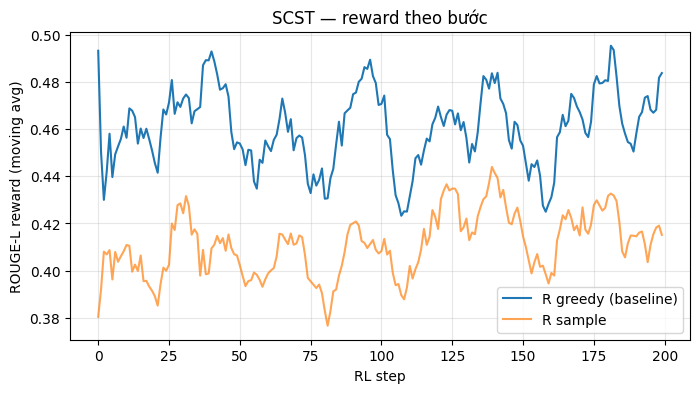

Đã lưu: /kaggle/working/nlp_summarization/checkpoints_pretrained/pretrained_rl_reward.png


In [14]:
if rl_history:
    steps = [h['step'] for h in rl_history]
    def smooth(xs, w=10):
        out = []
        for i in range(len(xs)):
            lo = max(0, i - w + 1); out.append(sum(xs[lo:i+1]) / (i - lo + 1))
        return out
    plt.figure(figsize=(8, 4))
    plt.plot(steps, smooth([h['R_greedy'] for h in rl_history]), label='R greedy (baseline)')
    plt.plot(steps, smooth([h['R_sample'] for h in rl_history]), label='R sample', alpha=0.7)
    plt.xlabel('RL step'); plt.ylabel('ROUGE-L reward (moving avg)')
    plt.title('SCST — reward theo bước'); plt.legend(); plt.grid(alpha=0.3)
    rl_png = cfg.ckpt_dir / 'pretrained_rl_reward.png'
    plt.savefig(rl_png, dpi=150, bbox_inches='tight'); plt.show()
    print('Đã lưu:', rl_png)
else:
    print('RUN_RL=False → bỏ qua biểu đồ RL')

In [15]:
# Đánh giá LoRA + RL (mô hình sau SCST chính là peft_model)
if rl_history:
    print('Evaluating LoRA + SCST...')
    rl_res, _, rl_preds = evaluate_hf_model(peft_model, desc='LoRA+RL')
else:
    rl_res, rl_preds = None, None
    print('RL not enabled')

Evaluating LoRA + SCST...


Eval LoRA+RL:   0%|          | 0/300 [00:00<?, ?it/s]

{'rouge1': 0.7363, 'rouge2': 0.4513, 'rougeL': 0.4755, 'bleu': 0.3131, 'chrf': 0.4796, 'bertscore_f1': 0.7757}


## 12. Bảng so sánh: Zero-shot vs LoRA vs LoRA + RL

Bảng định lượng so sánh mô hình gốc (zero-shot), sau fine-tune LoRA, và sau học tăng cường SCST.

In [16]:
RUN_ZEROSHOT = True
zs_res, zs_preds = None, None
if RUN_ZEROSHOT:
    print('Loading ViT5-base for zero-shot eval...')
    _zs = AutoModelForSeq2SeqLM.from_pretrained(cfg.model_name).to(device)
    zs_res, _, zs_preds = evaluate_hf_model(_zs, desc='zero-shot')
    del _zs; free_mem()

Loading ViT5-base for zero-shot eval...


Eval zero-shot:   0%|          | 0/300 [00:00<?, ?it/s]

{'rouge1': 0.5692, 'rouge2': 0.2339, 'rougeL': 0.2985, 'bleu': 0.0863, 'chrf': 0.2519, 'bertscore_f1': 0.6713}


In [17]:
rows = []
def _row(tag, res):
    if res is None: return
    rows.append({'Model': tag, 'ROUGE-1': res['rouge1'], 'ROUGE-2': res['rouge2'],
                 'ROUGE-L': res['rougeL'], 'BLEU': res['bleu'], 'chrF': res.get('chrf', None),
                 'BERTScore-F1': res.get('bertscore_f1', None)})

_row('ViT5-base (zero-shot)', zs_res)
_row('ViT5-base + LoRA', lora_res)
_row('ViT5-base + LoRA + SCST (RL)', rl_res)

comp_df = pd.DataFrame(rows)
print('=== Eval Results (Scale 0-1) ===')
print(comp_df.to_string(index=False))
print()
print(comp_df.to_markdown(index=False))
comp_df.to_csv(cfg.ckpt_dir / 'comparison.csv', index=False)

=== Eval Results (Scale 0-1) ===
                       Model  ROUGE-1  ROUGE-2  ROUGE-L   BLEU   chrF  BERTScore-F1
       ViT5-base (zero-shot)   0.5692   0.2339   0.2985 0.0863 0.2519        0.6713
            ViT5-base + LoRA   0.7269   0.4453   0.4767 0.3009 0.4608        0.7802
ViT5-base + LoRA + SCST (RL)   0.7363   0.4513   0.4755 0.3131 0.4796        0.7757

| Model                        |   ROUGE-1 |   ROUGE-2 |   ROUGE-L |   BLEU |   chrF |   BERTScore-F1 |
|:-----------------------------|----------:|----------:|----------:|-------:|-------:|---------------:|
| ViT5-base (zero-shot)        |    0.5692 |    0.2339 |    0.2985 | 0.0863 | 0.2519 |         0.6713 |
| ViT5-base + LoRA             |    0.7269 |    0.4453 |    0.4767 | 0.3009 | 0.4608 |         0.7802 |
| ViT5-base + LoRA + SCST (RL) |    0.7363 |    0.4513 |    0.4755 | 0.3131 | 0.4796 |         0.7757 |


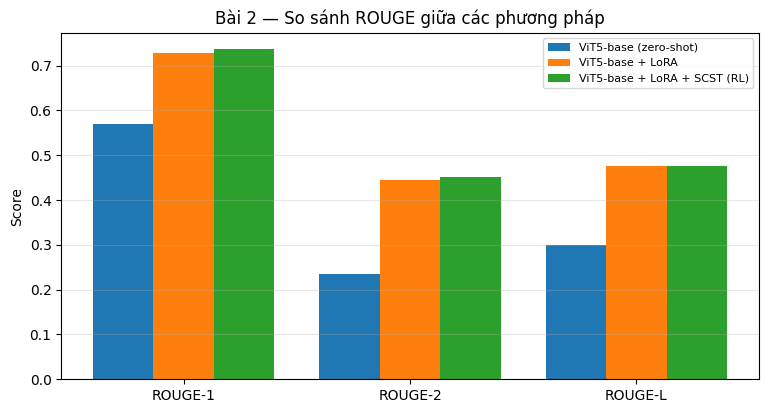

Đã lưu: /kaggle/working/nlp_summarization/checkpoints_pretrained/pretrained_comparison.png


In [18]:
# Biểu đồ cột so sánh ROUGE
if rows:
    import numpy as _np
    metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
    x = _np.arange(len(metrics)); w = 0.8 / len(rows)
    plt.figure(figsize=(9, 4.5))
    for j, r in enumerate(rows):
        plt.bar(x + j * w, [r[m] for m in metrics], w, label=r['Model'])
    plt.xticks(x + w * (len(rows) - 1) / 2, metrics)
    plt.ylabel('Score'); plt.title('Bài 2 — So sánh ROUGE giữa các phương pháp')
    plt.legend(fontsize=8); plt.grid(axis='y', alpha=0.3)
    cmp_png = cfg.ckpt_dir / 'pretrained_comparison.png'
    plt.savefig(cmp_png, dpi=150, bbox_inches='tight'); plt.show()
    print('Đã lưu:', cmp_png)

### 12.1 Ví dụ định tính trước/sau cải tiến

Dùng cho §V (đánh giá định tính) và §VI (error analysis) của báo cáo.

In [19]:
if lora_preds is not None:
    import random as _r; _r.seed(cfg.seed)
    show_idx = _r.sample(range(min(len(lora_preds), len(valid_df))), 3)
    for i in show_idx:
        print(f'--- Ví dụ {i} ---')
        print('SOURCE  :', str(valid_df.iloc[i][src_col])[:240], '...')
        print('REF     :', str(valid_df.iloc[i][tgt_col]))
        if zs_preds: print('ZEROSHOT:', zs_preds[i])
        print('LoRA    :', lora_preds[i])
        if rl_preds: print('LoRA+RL :', rl_preds[i])
        print()

--- Ví dụ 57 ---
SOURCE  : Trong video Reuters đăng ngày 8/11, một con chó robot được triển khai đi tuần xung quanh khu nghỉ dưỡng Mar-a-Lago. Xuồng tuần tra và cảnh sát có vũ trang cũng liên tục xuất hiện bên ngoài khu phức hợp. Sau khi đắc cử hôm 6/11, Trump vẫn hạ ...
REF     : Sau khi đắc cử tổng thống, khu nghỉ dưỡng Mar-a-Lago của Trump được tăng cường an ninh. Một con chó robot được triển khai đi tuần xung quanh khu nghỉ dưỡng, và xuồng tuần tra và cảnh sát có vũ trang cũng xuất hiện bên ngoài khu phức hợp. Ông Trump hạn chế xuất hiện trước công chúng và tập trung vào quá trình thiết lập chính quyền mới. Giám đốc truyền thông của Cơ quan Mật vụ Mỹ cho biết các biện pháp an ninh sẽ tiếp tục được tăng cường sau khi ông đắc cử tổng thống.
ZEROSHOT: * Cơ quan Mật vụ Mỹ cho biết.+ chúng tôi đang củng cố các biện pháp an ninh ở hạt Palm Beach, Florida và thành phố New York", ông nói. "Chúng tôi đang tăng cường an ninh". "Cơ quan này_,Z và[ cho hay.]!! Mỹ> vàj.& hạt Florida, Florida, v

## 13. Chạy dự đoán trên tập kiểm thử (Test Submission)

In [20]:
TEST_PATH = '/kaggle/input/datasets/thnhnamquch/test-set/test-00000-of-00001.parquet'  # <- Set test file path here

if TEST_PATH:
    test_raw = pd.read_parquet(TEST_PATH) if TEST_PATH.endswith('.parquet') else pd.read_csv(TEST_PATH)
    low = {c.lower(): c for c in test_raw.columns}
    test_src_col = next((low[k] for k in ['article', 'text', 'source', 'document', 'content'] if k in low), test_raw.columns[0])
    test_tgt_col = next((low[k] for k in ['summary', 'target', 'abstract', 'highlight'] if k in low), None)
    has_ref = test_tgt_col is not None
    print(f'Test: {len(test_raw)} samples | src={test_src_col} | tgt={test_tgt_col}')

    # Use best model (RL if available, else LoRA)
    best_model = peft_model if rl_res is not None else model
    best_model.eval()

    test_preds = []
    test_texts = test_raw[test_src_col].astype(str).values.tolist()
    # Áp dụng làm sạch văn bản (giống tập Train) để kết quả dự đoán tốt nhất
    if "clean_text" in globals():
        test_texts = [clean_text(t) for t in test_texts]
    for text in tqdm(test_texts, desc='Predicting'):
        test_preds.append(gen_summary(best_model, text))

    result_df = pd.DataFrame({'source': test_texts, 'prediction': test_preds})

    if has_ref:
        test_refs = test_raw[test_tgt_col].astype(str).values.tolist()
        if "clean_text" in globals():
            test_refs = [clean_text(r) for r in test_refs]
        result_df['reference'] = test_refs
        agg = {'rouge1': [], 'rouge2': [], 'rougeL': []}
        for r, p in zip(test_refs, test_preds):
            s = _scorer.score(r, p)
            for k in agg: agg[k].append(s[k].fmeasure)
        rouge = {k: round(sum(v)/len(v), 4) for k, v in agg.items()}
        bleu = round(sacrebleu.corpus_bleu(test_preds, [test_refs]).score / 100.0, 4)
        chrf = round(sacrebleu.corpus_chrf(test_preds, [test_refs]).score / 100.0, 4)
        print(f'\n=== Test Results (Scale 0-1) ===')
        print(f'  ROUGE-1: {rouge["rouge1"]}')
        print(f'  ROUGE-2: {rouge["rouge2"]}')
        print(f'  ROUGE-L: {rouge["rougeL"]}')
        print(f'  BLEU: {bleu}')
        print(f'  chrF: {chrf}')
        try:
            from bert_score import score as bs
            _, _, F1 = bs(test_preds, test_refs, lang='vi', verbose=False, batch_size=4, device=str(device))
            print(f'  BERTScore-F1: {round(F1.mean().item(), 4)}')
        except: pass

    out_path = cfg.ckpt_dir / 'test_predictions.csv'
    result_df.to_csv(out_path, index=False)
    print(f'\nSaved {len(test_preds)} predictions -> {out_path}')
else:
    print('No test path provided. Please set TEST_PATH.')


Test: 1344 samples | src=article | tgt=summary


Predicting:   0%|          | 0/1344 [00:00<?, ?it/s]


=== Test Results (Scale 0-1) ===
  ROUGE-1: 0.7362
  ROUGE-2: 0.4512
  ROUGE-L: 0.4717
  BLEU: 0.3118
  chrF: 0.4766
  BERTScore-F1: 0.7754

Saved 1344 predictions -> /kaggle/working/nlp_summarization/checkpoints_pretrained/test_predictions.csv
